The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

column names: Variable Type

date : string
venue : string
stage : string
team1 : string
team2 : string
toss_winner : string
toss_decision : string
first_ings_score : integer
second_ings_score : integer
match_winner : string
won_by : string
margin : integer
player_of_the_match : string
top_scorer : string
highscore : integer
best_bowling : string
best_bowling_fgure : string
gure : string

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('IPL.csv')
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [5]:
df.shape # check the size of rows and columns

(74, 20)

In [6]:
# another method
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


In [7]:
# lets see how many columns have null values in total
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

1)which team won the most matches

In [13]:

match_wins=df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'Most match wins by team')

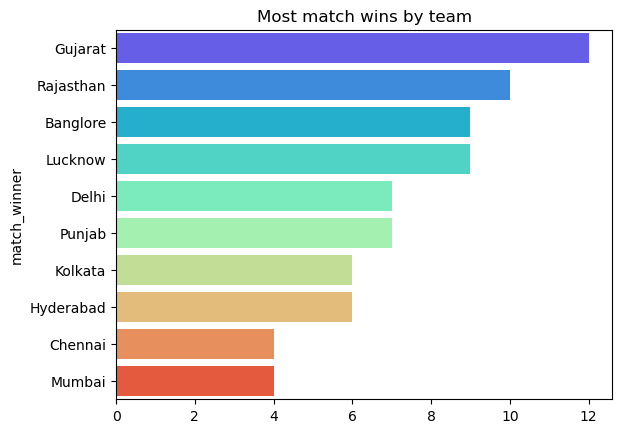

In [12]:
sns.barplot(x=match_wins.values, y=match_wins.index, palette='rainbow')
plt.title("Most match wins by team")

2) Toss decision trends 

Text(0.5, 1.0, 'Toss decision trends ')

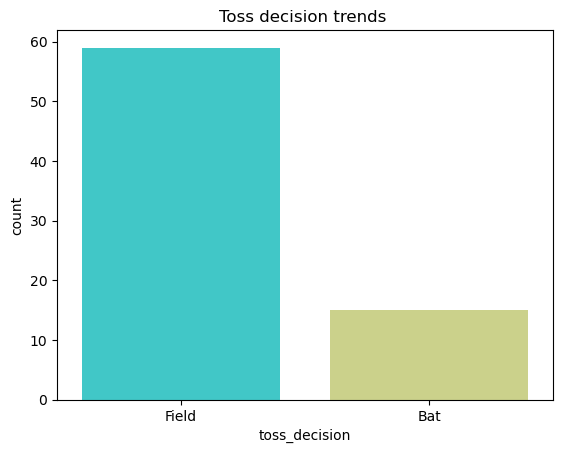

In [15]:
sns.countplot(x=df['toss_decision'], palette='rainbow')
plt.title("Toss decision trends ")

3) Toss winner vs Match Winner 

In [18]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count() # no of matches in which toss winner and match winner is same 

In [19]:
percentage=(count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

4) How do teams won? won by wickets or runs 

<Axes: xlabel='won_by', ylabel='count'>

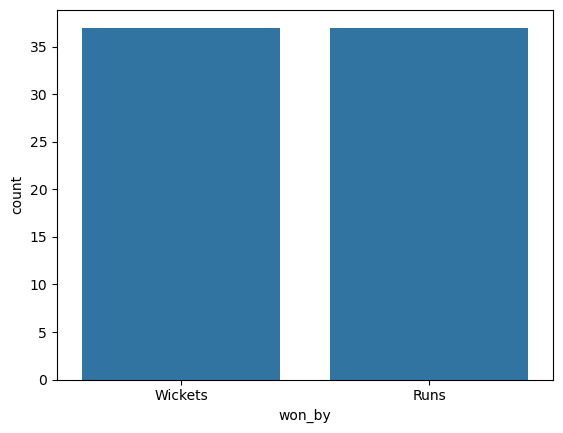

In [20]:
sns.countplot(x=df['won_by'])

Key Player Performances 

In [24]:
count=df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

<Axes: ylabel='player_of_the_match'>

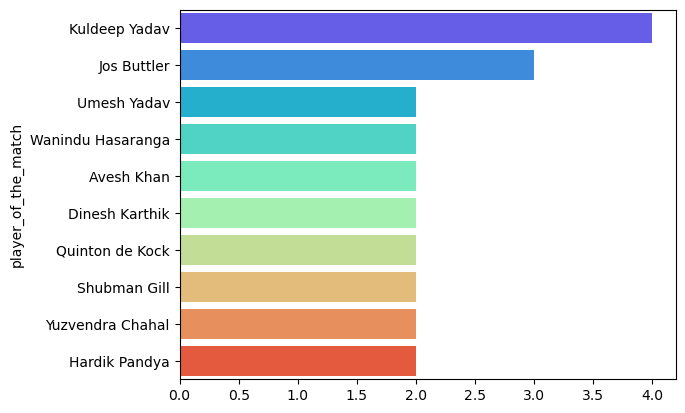

In [26]:
sns.barplot(x=count.values, y=count.index, palette='rainbow')

Top Scores - work with more than two columns use group by on one colun and extract other 

In [28]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

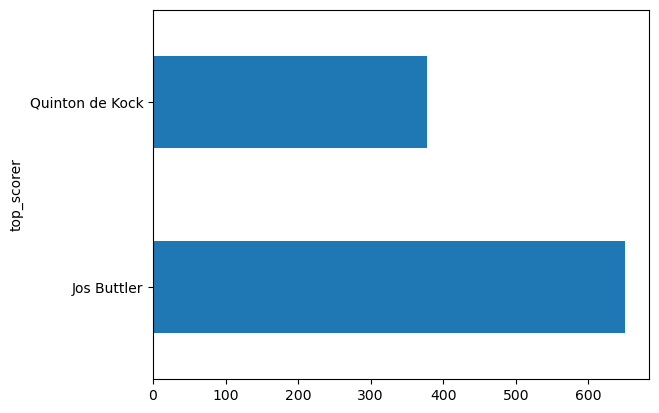

In [30]:
high.plot(kind='barh')

Best Bowling figures- use group by 

In [32]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False)
top_bowlers

best_bowling
Yuzvendra Chahal      17
Kuldeep Yadav         11
Rashid Khan           11
Jasprit Bumrah        11
Avesh Khan            10
Josh Hazlewood        10
Kagiso Rabada         10
Wanindu Hasaranga      9
Umran Malik            9
T Natarajan            8
Maheesh Theekshana     7
Lockie Ferguson        7
Andre Russell          7
Mohsin Khan            7
Daniel Sams            7
Dwayne Bravo           6
Prasidh Krishna        6
Harshal Patel          6
Mohammed Shami         5
Umesh Yadav            4
Hardik Pandya          4
Mukesh Choudhary       4
Odean Smith            4
Shardul Takur          4
Ravi Bishnoi           4
Kuldeep Sen            4
Harpreet Brar          3
Moeen Ali              3
Khaleel Ahmed          3
Ramandeep Singh        3
Rahul Chahar           3
Krunal Pandya          3
Prashant Solanki       2
Rilley Meredith        2
Pradeep Sangwan        2
Murugan Ashwin         2
Tim Southee            2
Trent Boult            2
Mohammed Siraj         2
Chetan Sakar

<Axes: ylabel='best_bowling'>

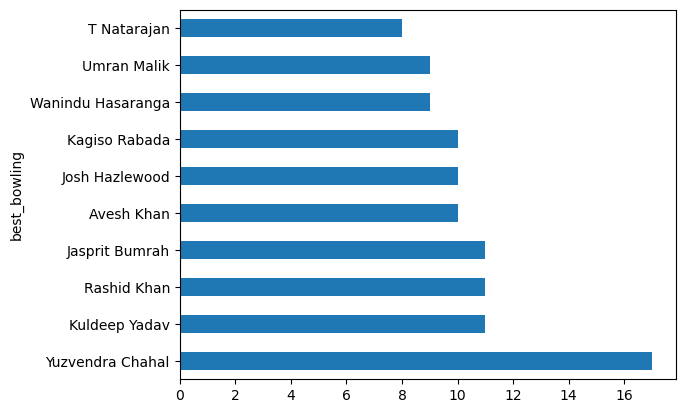

In [33]:
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')

most matches played by venue


In [37]:
venue_counts=df['venue'].value_counts()
venue_counts

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

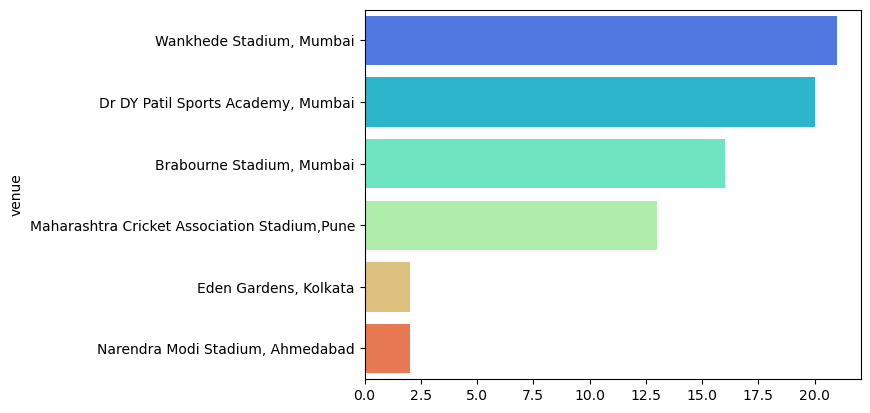

In [38]:
sns.barplot(y=venue_counts.index, x=venue_counts.values, palette='rainbow')

Who won the highes tmargin by runs 

In [39]:
df[df['won_by']=='Runs']

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3
8,9,"April 2,2022","Dr DY Patil Sports Academy, Mumbai",Mumbai,Rajasthan,Group,Mumbai,Field,193,8,...,8,Rajasthan,Runs,23,Jos Buttler,Jos Buttler,100,Jasprit Bumrah,3--17,3
9,10,"April 2,2022","Maharashtra Cricket Association Stadium,Pune",Delhi,Gujarat,Group,Delhi,Field,171,6,...,9,Gujarat,Runs,14,Lockie Ferguson,Shubman Gill,84,Lockie Ferguson,4--28,4
10,11,"April 3,2022","Brabourne Stadium, Mumbai",Chennai,Punjab,Group,Chennai,Field,180,8,...,10,Punjab,Runs,54,Liam Livingstone,Liam Livingstone,60,Rahul Chahar,3--25,3
11,12,"April 4,2022","Dr DY Patil Sports Academy, Mumbai",Hyderabad,Lucknow,Group,Hyderabad,Field,169,7,...,9,Lucknow,Runs,12,Avesh Khan,KL Rahul,68,Avesh Khan,4--24,4
18,19,"April 10,2022","Brabourne Stadium, Mumbai",Delhi,Kolkata,Group,Kolkata,Field,215,5,...,10,Delhi,Runs,44,Kuldeep Yadav,David Warner,61,Kuldeep Yadav,4--35,4
19,20,"April 10,2022","Wankhede Stadium, Mumbai",Lucknow,Rajasthan,Group,Lucknow,Field,165,6,...,8,Rajasthan,Runs,3,Yuzvendra Chahal,Shimron Hetmyer,59,Yuzvendra Chahal,4--41,4
21,22,"April 12,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Chennai,Group,Banglore,Field,216,4,...,9,Chennai,Runs,23,Shivam Dube,Shivam Dube,95,Maheesh Theekshana,4--33,4
22,23,"April 13,2022","Maharashtra Cricket Association Stadium,Pune",Mumbai,Punjab,Group,Mumbai,Field,198,5,...,9,Punjab,Runs,12,Mayank Agarwal,Shikhar Dhawan,70,Odean Smith,4--30,4
23,24,"April 14,2022","Dr DY Patil Sports Academy, Mumbai",Gujarat,Rajasthan,Group,Rajasthan,Field,192,4,...,9,Gujarat,Runs,37,Hardik Pandya,Hardik Pandya,87,Lockie Ferguson,3--23,3


In [40]:
df[df['won_by']=='Runs'].sort_values(by='margin', ascending=False).head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
54,55,"May 8,2022","Dr DY Patil Sports Academy, Mumbai",Chennai,Delhi,Group,Delhi,Field,208,6,...,10,Chennai,Runs,91,Devon Conway,Devon Conway,87,Moeen Ali,3--13,3


In [41]:
df[df['won_by']=='Runs'].sort_values(by='margin', ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


Which player has the highest individual score 

In [43]:
df[df['highscore']==df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Which bowler has the best bowling figures 

In [44]:
df[df['highest_wickets']==df['highest_wickets'].max()]

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
29,30,"April 18,2022","Brabourne Stadium, Mumbai",Kolkata,Rajasthan,Group,Kolkata,Field,217,5,...,10,Rajasthan,Runs,7,Yuzvendra Chahal,Jos Buttler,103,Yuzvendra Chahal,5--40,5
39,40,"April 27,2022","Wankhede Stadium, Mumbai",Gujarat,Hyderabad,Group,Gujarat,Field,195,6,...,5,Gujarat,Wickets,5,Umran Malik,W. Saha,68,Umran Malik,5--25,5
53,54,"May 8,2022","Wankhede Stadium, Mumbai",Banglore,Hyderabad,Group,Banglore,Bat,192,3,...,10,Banglore,Runs,67,Wanindu Hasaranga,Faf du Plessis,73,Wanindu Hasaranga,5--18,5
55,56,"May 9,2022","Dr DY Patil Sports Academy, Mumbai",Kolkata,Mumbai,Group,Mumbai,Field,165,9,...,10,Kolkata,Runs,52,Jasprit Bumrah,Ishan Kishan,51,Jasprit Bumrah,5--10,5


In [45]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
